# Домашнее задание 5. Градиентный спуск. (10 баллов + 2.5 бонус)

В этом домашнем задании вы напишете градиентный спуск для линейной регрессии, а так же посмотрите, как он ведёт себя с разными параметрами и разными функциями потерь.

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

In [19]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

## Часть 1. Градиентный спуск (5 баллов)

Для начала давайте вспомним самый простой функционал ошибки, который мы применяем в задаче регрессии — Mean Squared Error:

$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2
$$

где $x_i$ — это $i$-ый объект датасета, $y_i$ — правильный ответ для $i$-го объекта, а $w$ — веса нашей линейной модели.

Как мы помним, для линейной модели, его можно записать в матричном виде вот так:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2
$$

где $X$ — это матрица объекты-признаки, а $y$ — вектор правильных ответов

Для того чтобы воспользоваться методом градиентного спуска, нам нужно посчитать градиент нашего функционала. Для MSE он будет выглядеть так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y)
$$

Ниже приведён базовый класс `BaseLoss`, который мы будем использовать для реализации всех наших лоссов. Менять его не нужно. У него есть два абстрактных метода:
1. Метод `calc_loss`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения лосса
2. Метод `calc_grad`, который будет принимать на вход объекты `x`, правильные ответы `y` и веса `w` и вычислять значения градиента (вектор)

In [20]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

Теперь давайте напишем реализацию этого абстрактоного класса: Mean Squared Error лосс.

**Задание 1.1 (5/8 балла):** Реализуйте класс `MSELoss`

Он должен вычислять лосс и градиент по формулам наверху

In [21]:
from numpy import linalg as LA
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        # -- YOUR CODE HERE --
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        return 1/X.shape[0] * LA.norm(X.dot(w) - y) ** 2

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE --
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        return 2/X.shape[0] * X.transpose().dot(X.dot(w) - y)

Теперь мы можем создать объект `MSELoss` и при помощи него вычислять значение нашей функции потерь и градиенты:

In [22]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


Теперь когда у нас есть всё для вычисления градиента, давайте напишем наш градиентный спуск. Напомним, что формула для одной итерации градиентного спуска выглядит следующим образом:

$$
w^t = w^{t-1} - \eta \nabla_{w} Q(w^{t-1}, X, y)
$$

Где $w^t$ — значение вектора весов на $t$-ой итерации, а $\eta$ — параметр learning rate, отвечающий за размер шага.

**Задание 1.2 (5/8 балла):** Реализуйте функцию `gradient_descent`

Функция должна принимать на вход начальное значение весов линейной модели `w_init`, матрицу объектов-признаков `X`, 
вектор правильных ответов `y`, объект функции потерь `loss`, размер шага `lr` и количество итераций `n_iterations`.

Функция должна реализовывать цикл, в котором происходит шаг градиентного спуска (градиенты берутся из `loss` посредством вызова метода `calc_grad`) по формуле выше и возвращать 
траекторию спуска (список из новых значений весов на каждом шаге)

In [73]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    w_history = []
    w = w_init.copy()
    for k in range(n_iterations):
        w_history.append(w.copy())
        w -= lr * loss.calc_grad(X, y, w)
    return w_history

Теперь создадим синтетический датасет и функцию, которая будет рисовать траекторию градиентного спуска по истории:

In [74]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [75]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

425.58917680450264
0.867064439564965


In [76]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # visualize the level set
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # visualize trajectory
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

**Задание 1.3 (5/8 балла):** При помощи функций `gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`). Используйте не менее четырёх разных значений для `lr`. 

Сделайте и опишите свои выводы о том, как параметр `lr` влияет на поведение градиентного спуска

Подсказки:
* Функция `gradient_descent` возвращает историю весов, которую нужно подать в функцию `plot_gd`
* Хорошие значения для `lr` могут лежать в промежутке от 0.0001 до 0.1

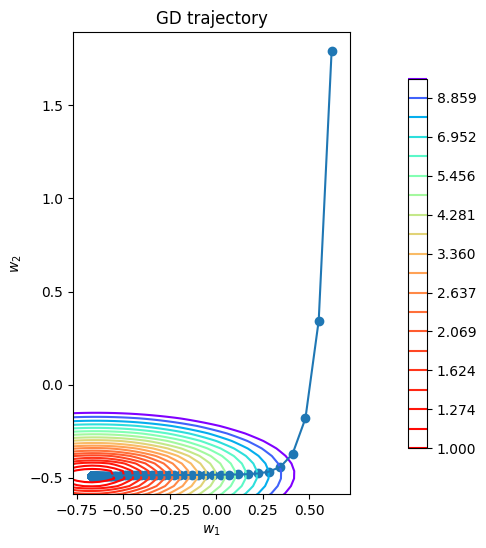

In [104]:
np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

loss = MSELoss()

history = gradient_descent(w_init, X, y, loss, 0.004, 1000)
plot_gd(history, X, y, loss)

Теперь реализуем стохастический градиентный спуск

**Задание 1.4 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent`

Функция должна принимать все те же параметры, что и функция `gradient_descent`, но ещё параметр `batch_size`, отвечающий за размер батча. 

Функция должна как и раньше реализовывать цикл, в котором происходит шаг градиентного спуска, но на каждом шаге считать градиент не по всей выборке `X`, а только по случайно выбранной части.

Подсказка: для выбора случайной части можно использовать [`np.random.choice`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) с правильным параметром `size`, чтобы выбрать случайные индексы, а потом проиндексировать получившимся массивом массив `X`:
```
batch_indices = np.random.choice(X.shape[0], size=batch_size, replace=False)
batch = X[batch_indices]
```

In [105]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    w_history = []
    w = w_init.copy()
    n_objects = X.shape[0]

    for _ in range(n_iterations):
        w_history.append(w.copy())
        batch_indices = np.random.choice(n_objects, size = batch_size, replace = False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]
        grad = loss.calc_grad(X_batch, y_batch, w)
        w -= lr * grad
    return w_history

**Задание 1.5 (5/8 балла):** При помощи функций `stochastic_gradient_descent` и  `plot_gd` нарисуйте траекторию градиентного спуска для разных значений длины шага (параметра `lr`) и размера подвыборки (параметра `batch_size`). Используйте не менее четырёх разных значений для `lr` и `batch_size`. 

Сделайте и опишите свои выводы о том, как параметры  `lr` и `batch_size` влияют на поведение стохастического градиентного спуска. Как отличается поведение стохастического градиентного спуска от обычного?

Обратите внимание, что в нашем датасете всего 300 объектов, так что `batch_size` больше этого числа не будет иметь смысла.

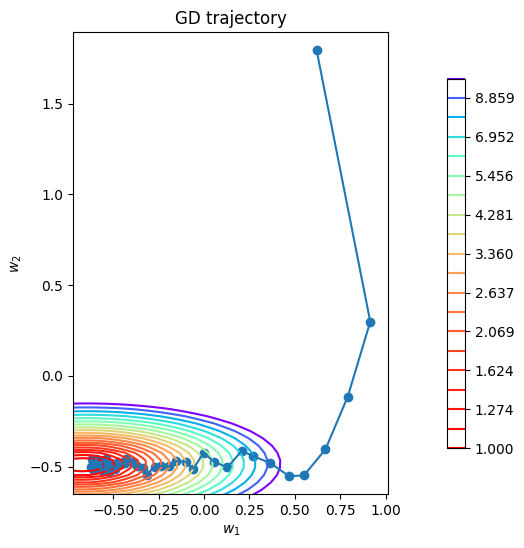

In [106]:
np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 20
num_steps = 50
lr = 0.005

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

loss = MSELoss()

w_history = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, num_steps)
plot_gd(w_history, X, y, loss)

Вы могли заметить, что поведение градиентного спуска, особенно стохастической версии, очень сильно зависит от размера шага. 

Как правило, в начале спуска мы хотим делать большие шаги, чтобы поскорее подойти поближе к минимуму, а позже мы уже хотим делать шаги маленькие, чтобы более точнее этого минимума достичь и не "перепрыгнуть" его. 

Чтобы достичь такого поведения мы можем постепенно уменьшать длину шага с увеличением номера итерации. Сделать это можно, например, вычисляя на каждой итерации длину шага по следующей формуле:

$$
    \eta_t
    =
    \lambda
    \left(
        \frac{s_0}{s_0 + t}
    \right)^p
$$

где $\eta_t$ — длина шага на итерации $t$, $\lambda$ — начальная длина шага (параметр `lr` у нас), $s_0$ и $p$ — настраиваемые параметры.

**Задание 1.6 (5/8 балла):** Реализуйте функцию `stochastic_gradient_descent` на этот раз с затухающим шагом по формуле выше. Параметр $s_0$ возьмите равным 1. Параметр $p$ возьмите из нового аргумента функции `p`.

In [107]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float -- значение степени в формуле затухания длины шага
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    # -- YOUR CODE HERE --
    w_history = []
    w = w_init.copy()
    n_objects = X.shape[0]

    for k in range(n_iterations):
        w_history.append(w.copy())
        batch_indices = np.random.choice(n_objects, size = batch_size, replace = False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]
        grad = loss.calc_grad(X_batch, y_batch, w)
        w -= lr * (1/(1+k))** p * grad
    return w_history

**Задание 1.7 (5/8 балла):** При помощи новой функции `stochastic_gradient_descent` и функции `plot_gd` нарисуйте траекторию градиентного спуска для разных значений параметра `p`. Используйте не менее четырёх разных значений для `p`. Хорошими могут быть значения, лежащие в промежутке от 0.1 до 1.
Параметр `lr` возьмите равным 0.01, а параметр `batch_size` равным 10.

Сделайте и опишите свои выводы о том, как параметр `p` влияет на поведение стохастического градиентного спуска

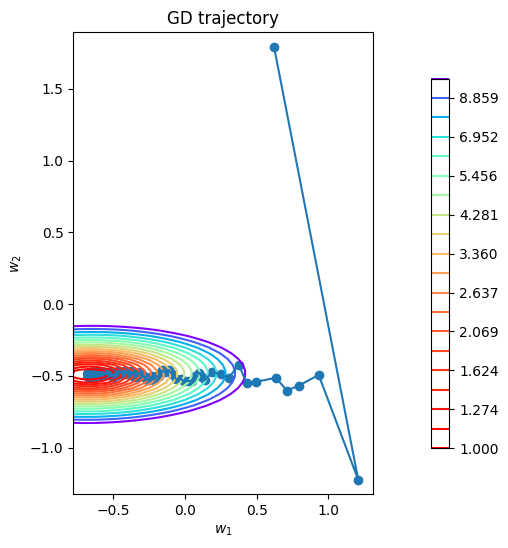

In [108]:
np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 1000
lr = 0.01
p = 0.5

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

loss = MSELoss()

w_history = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, p, num_steps)
plot_gd(w_history, X, y, loss)

**Задание 1.8 (5/8 балла):** Сравните сходимость обычного градиентного спуска и стохастичекой версии:
Нарисуйте график зависимости значения лосса (его можно посчитать при помощи метода `calc_loss`, используя $x$ и $y$ из датасета и $w$ с соответствующей итерации) от номера итерации для траекторий, полученных при помощи обычного и стохастического градиентного спуска с одинаковыми параметрами. Параметр `batch_size` возьмите равным 10.

Видно ли на данном графике преимущество SGD? Почему?

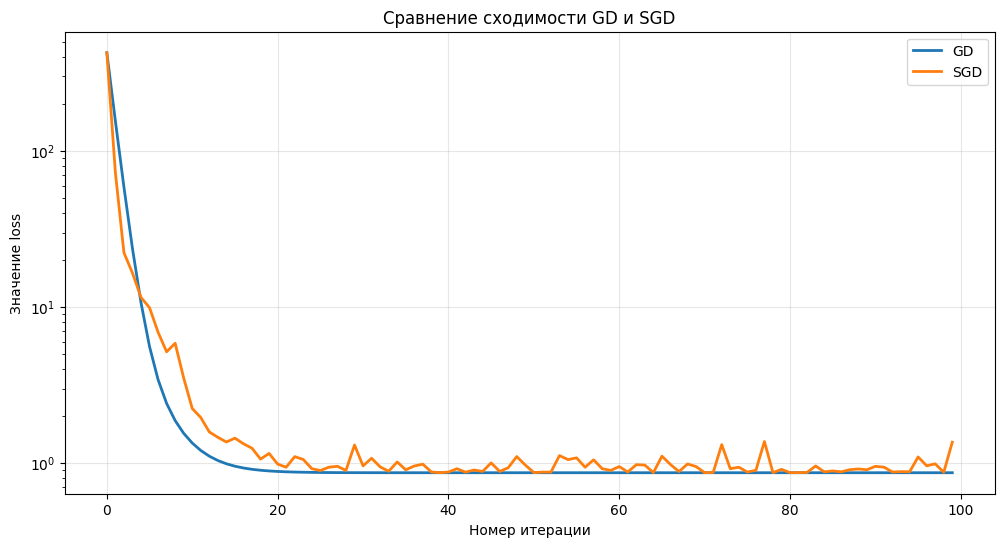

In [127]:
# -- YOUR CODE HERE --
np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 100
lr = 0.01
p = 0.1

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

loss = MSELoss()

gd_history = gradient_descent(w_init, X, y, loss, lr, num_steps)
sgd_history = stochastic_gradient_descent(w_init, X, y, loss, lr, batch_size, p, num_steps)
gd_losses = [loss.calc_loss(X, y, w) for w in gd_history]
sgd_losses = [loss.calc_loss(X, y, w) for w in sgd_history]

plt.figure(figsize=(12, 6))
plt.plot(gd_losses, label='GD', linewidth=2)
plt.plot(sgd_losses, label='SGD', linewidth=2)
plt.xlabel('Номер итерации')
plt.ylabel('Значение loss')
plt.title('Сравнение сходимости GD и SGD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # логарифмическая шкала для лучшей визуализации
plt.show()

## Часть 2. Линейная регрессия (5 баллов)

Теперь давайте напишем наш класс для линейной регрессии. Он будет использовать интерфейс, знакомый нам из библиотеки `sklearn`.

В методе `fit` мы будем подбирать веса `w` при помощи градиентного спуска нашим методом `gradient_descent`

В методе `predict` мы будем применять нашу регрессию к датасету, 

**Задание 2.1 (5/8 балла):** Допишите код в методах `fit` и `predict` класса `LinearRegression`

В методе `fit` вам нужно как-то инициализировать веса `w`, применить `gradient_descent` и сохранить последнюю `w` из траектории.

В методе `predict` вам нужно применить линейную регрессию и вернуть вектор ответов.

Обратите внимание, что объект лосса передаётся в момент инициализации и хранится в `self.loss`. Его нужно использовать в `fit` для `gradient_descent`.

In [129]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        # -- YOUR CODE HERE --
        # gd_history = gradient_descent(w_init, X, y, loss, lr, num_steps)
        w_init = np.random.uniform(-2, 2, (X.shape[1]))
        w_history = gradient_descent(w_init, X, y, self.loss, self.lr, 100)
        self.w = w_history[-1]
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена, то есть, что был вызван fit и в нём был установлен атрибут self.w
        assert hasattr(self, "w"), "Linear regression must be fitted first"
        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])
        # -- YOUR CODE HERE --
        return X.dot(self.w)

Теперь у нас есть наш класс линейной регрессии. Более того, мы можем управлять тем, какую функцию потерь мы оптимизируем, просто передавая разные классы в параметр `loss` при инициализации. 

Пока у нас нет никаких классов кроме `MSELoss`, но скоро они появятся.

Для `MSELoss` мы бы создавали наш объект линейной регрессии, например, так:

In [130]:
linear_regression = LinearRegression(MSELoss())

Применим нашу регрессию на реальном датасете. Загрузим датасет с машинами, который был у вас на семинарах:

In [138]:
import pandas as pd

X_raw = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data",
    header=None,
    na_values=["?"],
)
X_raw.head()
X_raw = X_raw[~X_raw[25].isna()].reset_index()

In [139]:
y = X_raw[25]
X_raw = X_raw.drop(25, axis=1)

**Задание 2.2 (5/8 балла):** Как обычно обработайте датасет всеми нужными методами, чтобы на нём можно было обучать линейную регрессию:

* Разделите датасет на обучающую и тестовую выборку
* Заполните пропуски
* Нормализуйте числовые признаки
* Закодируйте категориальные переменные

In [145]:
# -- YOUR CODE HERE --
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# Преобразуем названия столбцов в строки
X_raw.columns = X_raw.columns.astype(str)

# Автоматически определяем типы признаков
numeric_features = []
categorical_features = []

for col in X_raw.columns:
    # Проверяем тип данных в столбце
    if X_raw[col].dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        # Дополнительная проверка: можно ли преобразовать в число
        try:
            pd.to_numeric(X_raw[col], errors='raise')
            numeric_features.append(col)
        except (ValueError, TypeError):
            categorical_features.append(col)

print(f"Числовые признаки: {numeric_features}")
print(f"Категориальные признаки: {categorical_features}")

X_train, X_test, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)

# Создание пайплайнов для обработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Объединение в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Применяем преобразования к данным
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Размер обучающей выборки после обработки: {X_train_processed.shape}")
print(f"Размер тестовой выборки после обработки: {X_test_processed.shape}")

Числовые признаки: ['index', '0', '1', '9', '10', '11', '12', '13', '16', '18', '19', '20', '21', '22', '23', '24']
Категориальные признаки: ['2', '3', '4', '5', '6', '7', '8', '14', '15', '17']
Размер обучающей выборки после обработки: (160, 65)
Размер тестовой выборки после обработки: (41, 65)


**Задание 2.3 (5/8 балла):** Обучите написанную вами линейную регрессию на обучающей выборке

In [146]:
linear_regression.fit(X_train_processed, y_train)

**Задание 2.4 (5/8 балла):** Посчитайте ошибку обученной регрессии на обучающей и тестовой выборке при помощи метода `mean_squared_error` из `sklearn.metrics`.

In [156]:
from sklearn.metrics import mean_squared_error

# -- YOUR CODE HERE --

y_pred_train = linear_regression.predict(X_train_processed)
print(mean_squared_error(y_train, y_pred_train))

y_pred = linear_regression.predict(X_test_processed)
print(mean_squared_error(y_test, y_pred))

4841140.346911013
21287672.563226525


Наша модель переобучилась. Давайте как обычно в такой ситуации добавим к ней L2 регуляризацию. Для этого нам нужно написать новый класс лосса.

Формула функции потерь для MSE с L2 регуляризацией выглядит так:
$$
Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\langle x_i, w \rangle - y_i)^2 + \lambda ||w||^2
$$

Или в матричном виде:

$$
Q(w, X, y) = \frac{1}{\ell} || Xw - y ||^2 + \lambda ||w||^2
$$

Где $\lambda$ — коэффициент регуляризации

Градиент выглядит так:

$$
\nabla_w Q(w, X, y) = \frac{2}{\ell} X^T(Xw-y) + 2 \lambda w
$$

**Задание 2.5 (5/8 балла):** Реализуйте класс `MSEL2Loss`

Он должен вычислять лосс и градиент по формулам наверху

Подсказка: обратите внимание, что последний элемент вектора `w` — это bias (в классе `LinearRegression` к матрице `X` добавляется колонка из единиц — константный признак). Как мы знаем из лекций и семинаров, bias регуляризовать не нужно. Поэтому не забудьте убрать последний элемент из `w` при подсчёте слагаемого $\lambda||w||^2$ в `calc_loss` и занулить его при подсчёте слагаемого $2 \lambda w$ в `calc_grad`

In [157]:
class MSEL2Loss(BaseLoss):
    def __init__(self, coef: float = 1.0):
        """
        :param coef: коэффициент регуляризации (лямбда в формуле)
        """
        self.coef = coef

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета. Последний признак константный.
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии. Последний вес -- bias.
        :output: число -- значения функции потерь
        """
        # -- YOUR CODE HERE --
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        return 1/X.shape[0] * np.linalg.norm(X @ w - y) ** 2 + self.coef * np.linalg.norm(w[:-1]) ** 2

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE --
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        grad = 2 / X.shape[0] * X.T @ (X @ w - y)
        grad[:-1] += 2 * self.coef * w[:-1]
        return grad

Теперь мы можем использовать лосс с l2 регуляризацией в нашей регрессии, например, так:

In [208]:
linear_regression = LinearRegression(MSEL2Loss(0.1))

**Задание 2.6 (5/8 балла):** Обучите регрессию с лоссом `MSEL2Loss`. Подберите хороший коэффициент регуляризации и добейтесь улучшения результата на тестовой выборке. Сравните результат на обучающей и тестовой выборке с регрессией без регуляризации. 

In [211]:
# -- YOUR CODE HERE --

# Обучаем без регуляризации для сравнения
linear_regression_no_reg = LinearRegression(MSELoss())
linear_regression_no_reg.fit(X_train_processed, y_train)

y_train_pred_no_reg = linear_regression_no_reg.predict(X_train_processed)
y_test_pred_no_reg = linear_regression_no_reg.predict(X_test_processed)

mse_train_no_reg = mean_squared_error(y_train, y_train_pred_no_reg)
mse_test_no_reg = mean_squared_error(y_test, y_test_pred_no_reg)

print("Без регуляризации:")
print(f"  MSE на обучающей выборке: {mse_train_no_reg:.2f}")
print(f"  MSE на тестовой выборке: {mse_test_no_reg:.2f}")
print()

# Подбираем коэффициент регуляризации
coefs = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
best_coef = None
best_mse_test = float('inf')
best_model = None

for coef in coefs:
    linear_regression = LinearRegression(MSEL2Loss(coef))
    linear_regression.fit(X_train_processed, y_train)
    
    y_train_pred = linear_regression.predict(X_train_processed)
    y_test_pred = linear_regression.predict(X_test_processed)
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
        
    if mse_test < best_mse_test:
        best_mse_test = mse_test
        best_coef = coef
        best_model = linear_regression

print()
print(f"Лучший коэффициент регуляризации: {best_coef}")

# Обучаем с лучшим коэффициентом
linear_regression_best = LinearRegression(MSEL2Loss(best_coef))
linear_regression_best.fit(X_train_processed, y_train)

y_train_pred_best = linear_regression_best.predict(X_train_processed)
y_test_pred_best = linear_regression_best.predict(X_test_processed)

mse_train_best = mean_squared_error(y_train, y_train_pred_best)
mse_test_best = mean_squared_error(y_test, y_test_pred_best)

print("\nС лучшей регуляризацией:")
print(f"  MSE на обучающей выборке: {mse_train_best:.2f}")
print(f"  MSE на тестовой выборке: {mse_test_best:.2f}")
print()
print("Сравнение:")
print(f"  Улучшение на тестовой выборке: {mse_test_no_reg:.2f} -> {mse_test_best:.2f} ")

Без регуляризации:
  MSE на обучающей выборке: 3863347.57
  MSE на тестовой выборке: 14866332.07


Лучший коэффициент регуляризации: 0.01

С лучшей регуляризацией:
  MSE на обучающей выборке: 3968262.42
  MSE на тестовой выборке: 15639187.31

Сравнение:
  Улучшение на тестовой выборке: 14866332.07 -> 15639187.31 


В нашем датасете могут быть выбросы. На семинаре вам рассказывали, что с выбросами хорошо помогает бороться Huber Loss. Вдали от нуля он работает как Mean Absolute Error и не реагирует на выбросы так сильно, как MSE. Давайте его реализуем и применим в нашей регрессии.

Напомним, что функция потерь Huber Loss'а  выглядит так:


$$
    Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \phi_\varepsilon(z) = \begin{cases} \frac 1 2 z^2, - \varepsilon < z < \varepsilon, \\\varepsilon (|z| - \frac 1 2 \varepsilon), иначе \\ \end{cases}
$$


А градиент так:
$$
    \nabla_w Q(w, X, y) = \frac{1}{\ell} \sum\limits_{i=1}^\ell x_i \nabla_z \phi_\varepsilon (\langle x_i, w \rangle - y_i)
$$
$$
    \nabla_z \phi_\varepsilon(z) = \begin{cases} z, - \varepsilon < z < \varepsilon, \\\varepsilon \text{ sign}(z), иначе \\ \end{cases}
$$

**Задание 2.7 (5/8 балла):** Реализуйте класс `HuberLoss`

Он должен вычислять лосс и градиент по формулам наверху

In [212]:
class HuberLoss(BaseLoss):
    def __init__(self, eps: float) -> None:
        """
        :param eps: параметр huber loss из формулы
        """
        self.eps = eps

    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: число -- значения функции потерь
        """
        # -- YOUR CODE HERE --
        # Вычислите значение функции потерь при помощи X, y и w и верните его
        residuals = X @ w - y
        abs_residuals = np.abs(residuals)
        
        # Маски для разных случаев
        quadratic_mask = abs_residuals <= self.eps
        linear_mask = ~quadratic_mask
        
        # Квадратичная часть: 0.5 * z^2
        quadratic_loss = 0.5 * residuals[quadratic_mask] ** 2
        
        # Линейная часть: eps * (|z| - 0.5 * eps)
        linear_loss = self.eps * (abs_residuals[linear_mask] - 0.5 * self.eps)
        
        total_loss = np.sum(quadratic_loss) + np.sum(linear_loss)
        return total_loss / X.shape[0]

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :output: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        # -- YOUR CODE HERE --
        # Вычислите значение вектора градиента при помощи X, y и w и верните его
        residuals = X @ w - y
        abs_residuals = np.abs(residuals)
        
        # Производная phi по z
        phi_derivative = np.zeros_like(residuals)
        
        # Для |z| <= eps: производная = z
        quadratic_mask = abs_residuals <= self.eps
        phi_derivative[quadratic_mask] = residuals[quadratic_mask]
        
        # Для |z| > eps: производная = eps * sign(z)
        linear_mask = ~quadratic_mask
        phi_derivative[linear_mask] = self.eps * np.sign(residuals[linear_mask])
        
        # Градиент: (1/ℓ) * X.T @ phi_derivative
        grad = (X.T @ phi_derivative) / X.shape[0]
        return grad

**Задание 2.8 (5/8 балла):** Обучите регрессию с лоссом `HuberLoss`. Сравните результат на обучающей и тестовой выборке с регрессией, обученной c `MSELoss`.

In [216]:
# -- YOUR CODE HERE --
from sklearn.metrics import mean_squared_error
import numpy as np

# Обучаем с MSE Loss (для сравнения)
linear_regression_mse = LinearRegression(MSELoss())
linear_regression_mse.fit(X_train_processed, y_train)

y_train_pred_mse = linear_regression_mse.predict(X_train_processed)
y_test_pred_mse = linear_regression_mse.predict(X_test_processed)

mse_train_mse = mean_squared_error(y_train, y_train_pred_mse)
mse_test_mse = mean_squared_error(y_test, y_test_pred_mse)

print("MSELoss:")
print(f"  MSE на обучающей выборке: {mse_train_mse:.2f}")
print(f"  MSE на тестовой выборке: {mse_test_mse:.2f}")
print()

# Подбираем параметр eps для Huber Loss
eps_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100, 1000, 10000, 1000000]
best_eps = None
best_mse_test = float('inf')
best_model = None

print("Подбор параметра eps для HuberLoss:")
for eps in eps_values:
    linear_regression = LinearRegression(HuberLoss(eps))
    linear_regression.fit(X_train_processed, y_train)
    
    y_train_pred = linear_regression.predict(X_train_processed)
    y_test_pred = linear_regression.predict(X_test_processed)
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    
    print(f"  eps={eps}: train MSE={mse_train:.2f}, test MSE={mse_test:.2f}")
    
    if mse_test < best_mse_test:
        best_mse_test = mse_test
        best_eps = eps
        best_model = linear_regression

print()
print(f"Лучший параметр eps: {best_eps}")

# Обучаем с лучшим параметром
linear_regression_huber = LinearRegression(HuberLoss(best_eps))
linear_regression_huber.fit(X_train_processed, y_train)

y_train_pred_huber = linear_regression_huber.predict(X_train_processed)
y_test_pred_huber = linear_regression_huber.predict(X_test_processed)

mse_train_huber = mean_squared_error(y_train, y_train_pred_huber)
mse_test_huber = mean_squared_error(y_test, y_test_pred_huber)

print("\nHuberLoss с лучшим параметром:")
print(f"  MSE на обучающей выборке: {mse_train_huber:.2f}")
print(f"  MSE на тестовой выборке: {mse_test_huber:.2f}")
print()
print("Сравнение с MSELoss:")
print(f"  MSELoss test MSE: {mse_test_mse:.2f}")
print(f"  HuberLoss test MSE: {mse_test_huber:.2f}")
print(f"  Разница: {((mse_test_mse - mse_test_huber) / mse_test_mse * 100):.1f}%")

# Анализ остатков для понимания влияния выбросов
residuals_mse = np.abs(y_test - y_test_pred_mse)
residuals_huber = np.abs(y_test - y_test_pred_huber)

print("\nАнализ остатков на тестовой выборке:")
print(f"  MSELoss - средний абсолютный остаток: {np.mean(residuals_mse):.2f}")
print(f"  HuberLoss - средний абсолютный остаток: {np.mean(residuals_huber):.2f}")
print(f"  MSELoss - макс остаток: {np.max(residuals_mse):.2f}")
print(f"  HuberLoss - макс остаток: {np.max(residuals_huber):.2f}")

MSELoss:
  MSE на обучающей выборке: 3863534.13
  MSE на тестовой выборке: 14865405.73

Подбор параметра eps для HuberLoss:
  eps=0.1: train MSE=203664634.44, test MSE=368111949.05
  eps=0.5: train MSE=203280480.54, test MSE=367611627.79
  eps=1.0: train MSE=202655749.50, test MSE=366997081.94
  eps=2.0: train MSE=201590598.78, test MSE=365757037.77
  eps=5.0: train MSE=198438294.22, test MSE=362104837.42
  eps=10.0: train MSE=193264568.38, test MSE=356094945.77
  eps=20.0: train MSE=183220572.45, test MSE=344297563.78
  eps=50.0: train MSE=155353200.64, test MSE=311250607.98
  eps=100: train MSE=117000370.33, test MSE=264008032.81
  eps=1000: train MSE=9684954.69, test MSE=44846335.09
  eps=10000: train MSE=4822770.87, test MSE=18215806.71
  eps=1000000: train MSE=4708210.98, test MSE=17642453.88

Лучший параметр eps: 1000000

HuberLoss с лучшим параметром:
  MSE на обучающей выборке: 4707901.80
  MSE на тестовой выборке: 17641090.57

Сравнение с MSELoss:
  MSELoss test MSE: 14865405.

**Задание 3 (0.08/8 балла)**
Вставьте ваш любимый мем 2021 в ячейку ниже:

In [162]:
# -- YOUR MEME HERE --

### БОНУС (2.5 баллов)

Градиентный спуск — далеко не единственный метод оптимизации. 
Другой очень известный метод называется ["Алгоритм имитации отжига"](https://ru.wikipedia.org/wiki/%D0%90%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B8%D0%BC%D0%B8%D1%82%D0%B0%D1%86%D0%B8%D0%B8_%D0%BE%D1%82%D0%B6%D0%B8%D0%B3%D0%B0). Он не так часто используется для оптимизации моделей машинного обучения, но у вас есть уникальная возможность попробовать применить его к нашей любимой линейной регрессии.

**Задание (2.5 баллов)**:
Напишите алгоритм имитации отжига для оптимизации MSE линейной регрессии. 

Сравните результат с градиентным спуском по "траектории" и по финальному лоссу.

Подсказка: каждую новую точку (веса регресси в нашем случае) можно семплировать из некоторого случайного распределением с центром в текущей точке. Хорошо подойдут распределения с "тяжёлыми" хвостами, например, распределение Стьюдента с параметром количества степеней свободы в районе 3.
Это может выглядеть, например, так:
```
new_w = old_w + np.random.standard_t(3, size=old_w.shape)
```
С параметром распределения можно поэксперементировать: чем он больше, тем реже новые точки будут очень сильно уходить от старых.

Градиентный спуск:
  Начальный loss: 425.5892
  Финальный loss: 0.8671

Имитация отжига:
  SA (T0=100, rate=0.95, df=3):
    Начальный loss: 425.5892
    Финальный loss: 104.6333
  SA (T0=200, rate=0.99, df=3):
    Начальный loss: 425.5892
    Финальный loss: 1.4389
  SA (T0=100, rate=0.95, df=2 - тяжелые хвосты):
    Начальный loss: 425.5892
    Финальный loss: 15.8221


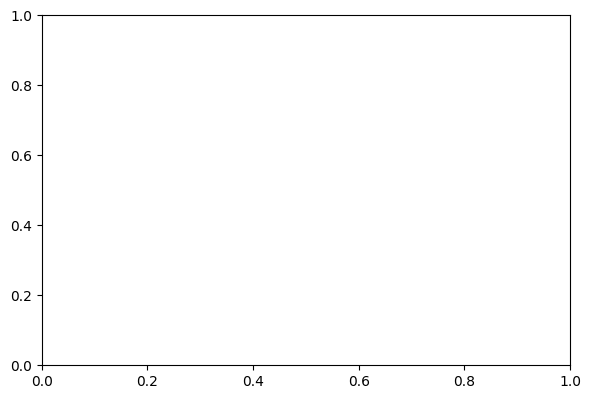

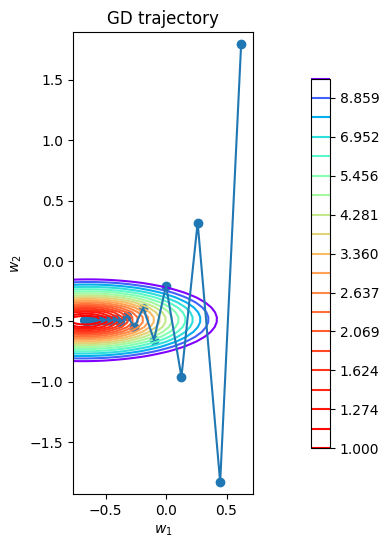

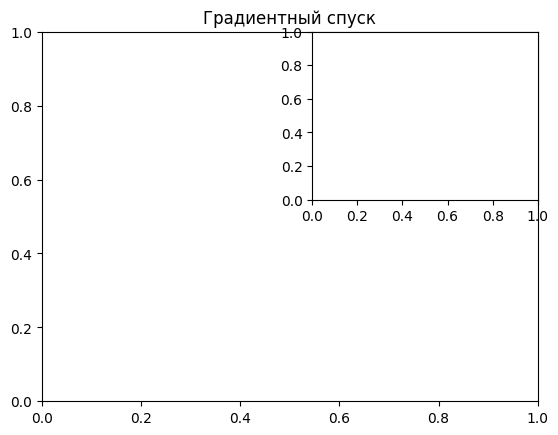

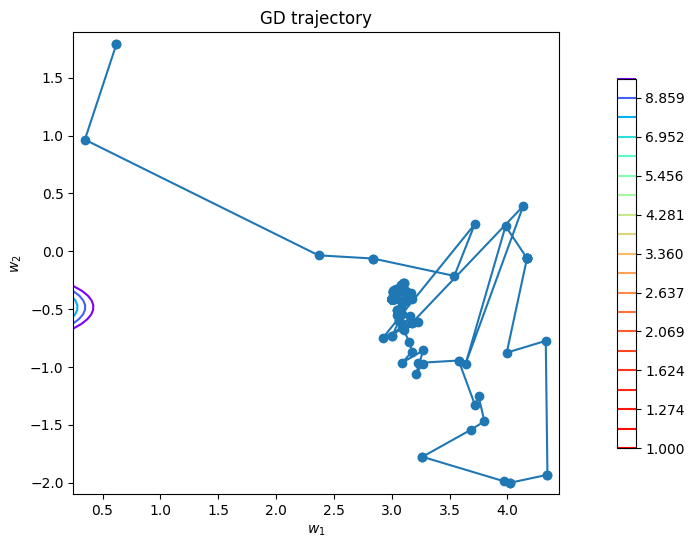

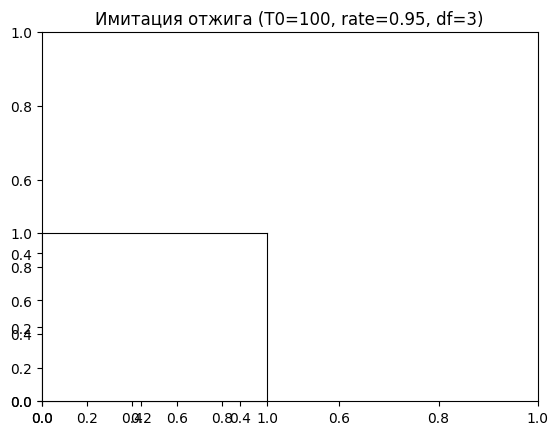

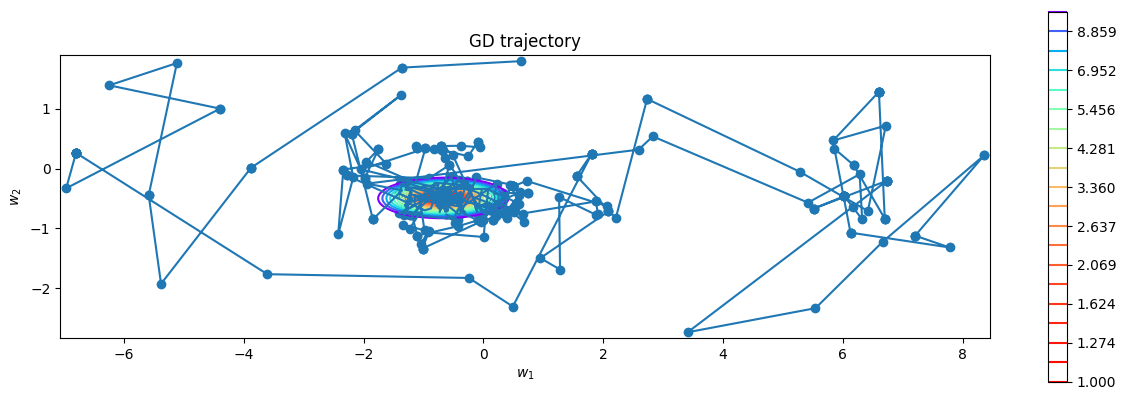

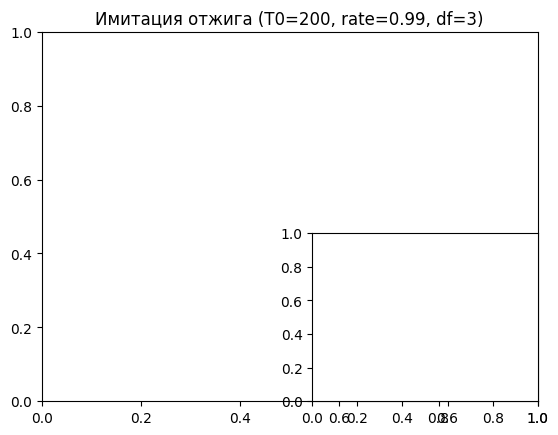

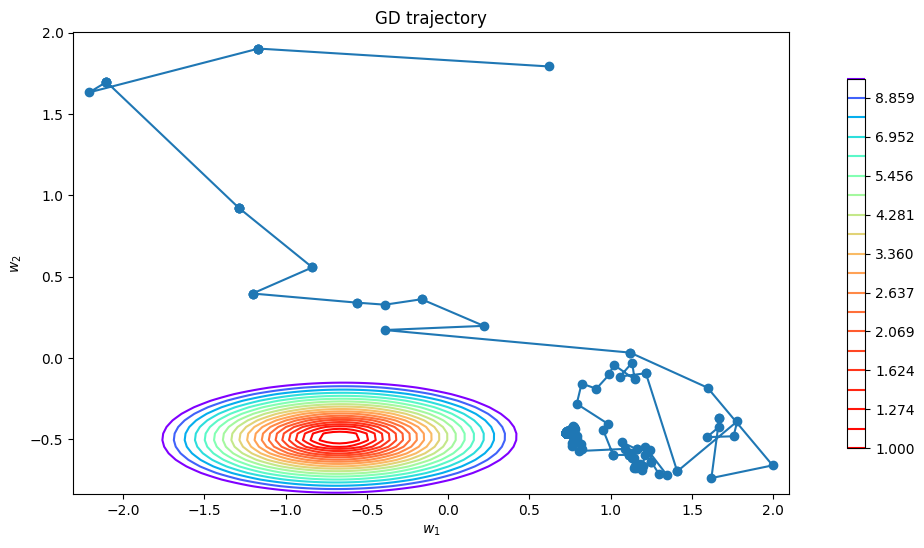

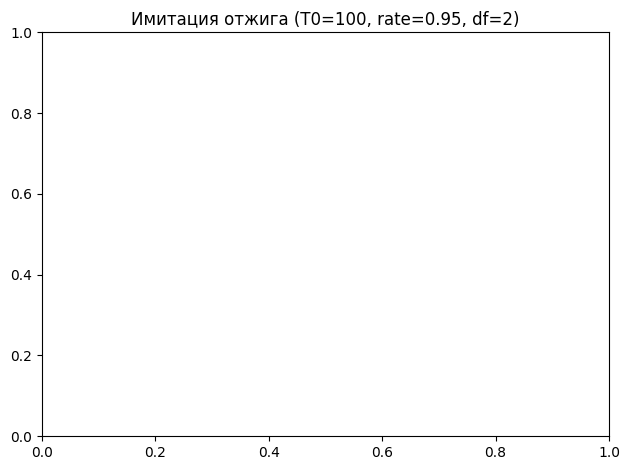

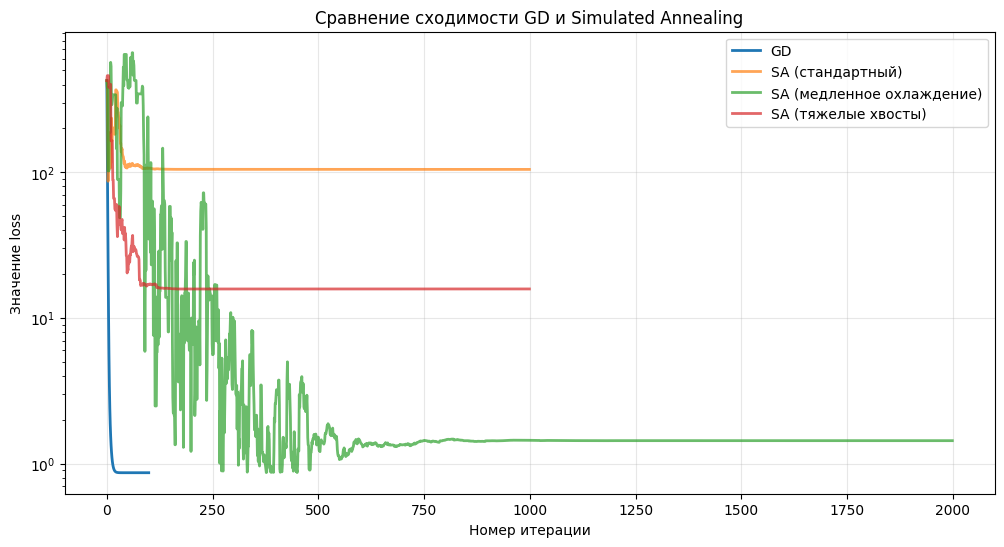


ВЫВОДЫ:

Градиентный спуск (GD):
- Быстрая сходимость к локальному минимуму
- Детерминированный характер движения
- Чувствителен к выбору learning rate

Имитация отжига (SA):
- Может исследовать более широкую область пространства
- Способен выходить из локальных минимумов благодаря вероятностному принятию худших решений
- Медленнее сходится, но может найти更好的 глобальный минимум
- Качество зависит от параметров: начальной температуры, скорости охлаждения и распределения шагов

Параметры SA:
- Начальная температура: определяет "активность" на ранних этапах
- Скорость охлаждения: баланс между исследованием и эксплуатацией
- Распределение шагов: тяжелые хвосты (маленькие df) позволяют делать большие скачки



In [217]:
# -- YOUR CODE HERE --
# -- YOUR CODE HERE --
class SimulatedAnnealing:
    """
    Алгоритм имитации отжига для оптимизации линейной регрессии
    """
    def __init__(self, loss: BaseLoss, initial_temp: float = 100.0, 
                 cooling_rate: float = 0.95, df: int = 3):
        """
        :param loss: функция потерь
        :param initial_temp: начальная температура
        :param cooling_rate: коэффициент охлаждения
        :param df: степени свободы для распределения Стьюдента (тяжелые хвосты)
        """
        self.loss = loss
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        self.df = df
        
    def optimize(self, w_init: np.ndarray, X: np.ndarray, y: np.ndarray, 
                 n_iterations: int = 10000) -> List[np.ndarray]:
        """
        Запуск алгоритма имитации отжига
        
        :param w_init: начальные веса
        :param X: матрица объекты-признаки
        :param y: вектор правильных ответов
        :param n_iterations: количество итераций
        :return: история весов на каждом шаге
        """
        w_history = []
        current_w = w_init.copy()
        current_loss = self.loss.calc_loss(X, y, current_w)
        temperature = self.initial_temp
        
        w_history.append(current_w.copy())
        
        for iteration in range(1, n_iterations):
            # Генерируем новое состояние с тяжелыми хвостами (распределение Стьюдента)
            step = np.random.standard_t(self.df, size=current_w.shape)
            new_w = current_w + step * temperature * 0.01  # масштабируем шаг температурой
            
            # Вычисляем новое значение функции потерь
            new_loss = self.loss.calc_loss(X, y, new_w)
            
            # Разница в качестве
            delta = new_loss - current_loss
            
            # Вероятность принятия худшего решения
            if delta < 0 or np.random.random() < np.exp(-delta / temperature):
                current_w = new_w
                current_loss = new_loss
            
            # Сохраняем историю
            w_history.append(current_w.copy())
            
            # Охлаждение
            temperature *= self.cooling_rate
        
        return w_history


# Сравнение градиентного спуска и имитации отжига
np.random.seed(1337)

n_features = 2
n_objects = 300
w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :]
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

loss = MSELoss()

# Градиентный спуск
print("Градиентный спуск:")
gd_history = gradient_descent(w_init, X, y, loss, 0.01, 100)
gd_losses = [loss.calc_loss(X, y, w) for w in gd_history]
print(f"  Начальный loss: {gd_losses[0]:.4f}")
print(f"  Финальный loss: {gd_losses[-1]:.4f}")

# Имитация отжига с разными параметрами
print("\nИмитация отжига:")

# Вариант 1: стандартные параметры
sa = SimulatedAnnealing(loss, initial_temp=100.0, cooling_rate=0.95, df=3)
sa_history = sa.optimize(w_init, X, y, 1000)
sa_losses = [loss.calc_loss(X, y, w) for w in sa_history]
print(f"  SA (T0=100, rate=0.95, df=3):")
print(f"    Начальный loss: {sa_losses[0]:.4f}")
print(f"    Финальный loss: {sa_losses[-1]:.4f}")

# Вариант 2: более медленное охлаждение
sa2 = SimulatedAnnealing(loss, initial_temp=200.0, cooling_rate=0.99, df=3)
sa2_history = sa2.optimize(w_init, X, y, 2000)
sa2_losses = [loss.calc_loss(X, y, w) for w in sa2_history]
print(f"  SA (T0=200, rate=0.99, df=3):")
print(f"    Начальный loss: {sa2_losses[0]:.4f}")
print(f"    Финальный loss: {sa2_losses[-1]:.4f}")

# Вариант 3: более тяжелые хвосты
sa3 = SimulatedAnnealing(loss, initial_temp=100.0, cooling_rate=0.95, df=2)
sa3_history = sa3.optimize(w_init, X, y, 1000)
sa3_losses = [loss.calc_loss(X, y, w) for w in sa3_history]
print(f"  SA (T0=100, rate=0.95, df=2 - тяжелые хвосты):")
print(f"    Начальный loss: {sa3_losses[0]:.4f}")
print(f"    Финальный loss: {sa3_losses[-1]:.4f}")

# Визуализация траекторий
plt.figure(figsize=(15, 10))

# Градиентный спуск
plt.subplot(2, 2, 1)
plot_gd(gd_history, X, y, loss)
plt.title("Градиентный спуск")

# Имитация отжига - вариант 1
plt.subplot(2, 2, 2)
plot_gd(sa_history, X, y, loss)
plt.title(f"Имитация отжига (T0=100, rate=0.95, df=3)")

# Имитация отжига - вариант 2
plt.subplot(2, 2, 3)
plot_gd(sa2_history, X, y, loss)
plt.title(f"Имитация отжига (T0=200, rate=0.99, df=3)")

# Имитация отжига - вариант 3
plt.subplot(2, 2, 4)
plot_gd(sa3_history, X, y, loss)
plt.title(f"Имитация отжига (T0=100, rate=0.95, df=2)")

plt.tight_layout()
plt.show()

# Сравнение сходимости по loss
plt.figure(figsize=(12, 6))
plt.plot(gd_losses, label='GD', linewidth=2)
plt.plot(sa_losses, label='SA (стандартный)', linewidth=2, alpha=0.7)
plt.plot(sa2_losses, label='SA (медленное охлаждение)', linewidth=2, alpha=0.7)
plt.plot(sa3_losses, label='SA (тяжелые хвосты)', linewidth=2, alpha=0.7)
plt.xlabel('Номер итерации')
plt.ylabel('Значение loss')
plt.title('Сравнение сходимости GD и Simulated Annealing')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

# Выводы
print("\n" + "="*50)
print("ВЫВОДЫ:")
print("="*50)
print("""
Градиентный спуск (GD):
- Быстрая сходимость к локальному минимуму
- Детерминированный характер движения
- Чувствителен к выбору learning rate

Имитация отжига (SA):
- Может исследовать более широкую область пространства
- Способен выходить из локальных минимумов благодаря вероятностному принятию худших решений
- Медленнее сходится, но может найти更好的 глобальный минимум
- Качество зависит от параметров: начальной температуры, скорости охлаждения и распределения шагов

Параметры SA:
- Начальная температура: определяет "активность" на ранних этапах
- Скорость охлаждения: баланс между исследованием и эксплуатацией
- Распределение шагов: тяжелые хвосты (маленькие df) позволяют делать большие скачки
""")